In [39]:
import ipywidgets as widgets
from IPython.display import display, HTML
#יצירת צ'ק ליסט קיים אינטרקטיבי ע"י בינה מלאכתוית כעזר למעקב אחר הפרוקיט והתקדמותו
# 1. עיצוב CSS מותאם ליישור לימין
display(
    HTML("""
<style>
    .rtl-checklist {
        direction: rtl !important;
        text-align: right !important;
    }
    .rtl-checklist .widget-checkbox {
        flex-direction: row-reverse !important;
        justify-content: flex-end !important;
    }
    .rtl-checklist .widget-checkbox label {
        margin-right: 8px !important;
        margin-left: 0px !important;
    }
</style>
""")
)

# 2. הגדרת המשימות והשלבים
tasks_data = [
    # חלק 1
    ("--- 1. הכנת הנתונים והסביבה ---", "header"),
    ("התקנת הספריות הנדרשות לפיתוח", "task"),
    ("הורדת ה-Dataset מ-Kaggle", "task"),
    ("טיפול בערכים חסרים בדאטה", "task"),
    ("בחירת 5–7 פיצ'רים + עמודת Target", "task"),
    # חלק 2
    ("--- 2. אימון המודל וה-Pipeline ---", "header"),
    ("המרת משתנים קטגוריאליים לערכים נומריים", "task"),
    ("פיצול הנתונים ל-Train ו-Test", "task"),
    ("בניית Pipeline המשולב StandardScaler ו-SVC", "task"),
    ("אימון ה-Pipeline על נתוני האימון (fit)", "task"),
    (
        "חישוב מטריקות הערכה (Accuracy, Confusion Matrix, Classification"
        " Report)",
        "task",
    ),
    ("שמירת ה-Pipeline והנתונים המורחבים לקובץ (.pkl)", "task"),
    # חלק 3
    ("--- 3. שרת FastAPI ---", "header"),
    ("הקמת תשתית השרת ב-FastAPI", "task"),
    (
        "מנגנון טעינת קובץ המודל בעליית השרת (כולל טיפול במקרה של קובץ חסר)",
        "task",
    ),
    ("יצירת Endpoint למידע כללי והיפר-פרמטרים (/model/info)", "task"),
    ("יצירת Endpoint לרשימת הפיצ'רים (/model/features)", "task"),
    ("יצירת Endpoint לנתוני הדגימות (/model/samples)", "task"),
    ("יצירת Endpoint למטריקות וביצועים (/model/metrics)", "task"),
    ("יצירת Endpoint לווקטורים התומכים (/model/support_vectors)", "task"),
    ("יצירת Endpoint לקבלת נתוני משתמש והחזרת חיזוי (/predict)", "task"),
    # חלק 4
    ("--- 4. ממשק המשתמש (HTML / Frontend) ---", "header"),
    (
        "בניית דף Dashboard מקיף להצגת נתוני ומטריקות המודל דרך ה-API",
        "task",
    ),
    ("הצגת גרף/ויזואליזציה של Margin Distribution / Decision Boundary", "task"),
    ("בניית דף טופס קליטת נתונים מהמשתמש (Loan Approval Checker)", "task"),
    ("חיבור כפתור ה-Check ל-API להרצת החיזוי", "task"),
    ("הצגת תוצאת החיזוי הוויזואלית (מאושר / לא מאושר)", "task"),
    # חלק 5
    ("--- 5. איכות, בדיקות והגשה ---", "header"),
    ("בדיקת התנהגות המערכת כשקובץ המודל חסר", "task"),
    ("כתיבת תיעוד (Docstrings) בקוד", "task"),
    ("הוספת לוגים (רשות - בונוס)", "task"),
    ("העלאת האפליקציה ל-Render (רשות - בונוס)", "task"),
    ("העלאת הקוד והמודל ל-GitHub", "task"),
]

checkboxes = []
ui_elements = []

# 3. יצירת רכיבי הממשק
for item, item_type in tasks_data:
    if item_type == "header":
        ui_elements.append(widgets.HTML(value=f"<h4 style='margin-top:15px; margin-bottom:5px; text-align:right;'>{item}</h4>"))
    else:
        cb = widgets.Checkbox(value=False, description=item, indent=False, layout=widgets.Layout(width='auto'))
        checkboxes.append(cb)
        ui_elements.append(cb)

# מד התקדמות
progress = widgets.IntProgress(
    value=0,
    min=0,
    max=len(checkboxes),
    description='התקדמות:',
    bar_style='info',
    orientation='horizontal',
    layout=widgets.Layout(width='300px')
)

progress_label = widgets.Label(value=f"0 / {len(checkboxes)} (0%)")

# עדכון מד ההתקדמות בזמן אמת
def update_progress(change):
    completed = sum(1 for cb in checkboxes if cb.value)
    progress.value = completed
    percent = int((completed / len(checkboxes)) * 100)
    progress_label.value = f"{completed} / {len(checkboxes)} ({percent}%)"
    
    if completed == len(checkboxes):
        progress.bar_style = 'success'
    else:
        progress.bar_style = 'info'

for cb in checkboxes:
    cb.observe(update_progress, names='value')

# 4. עטיפת כל הווידג'טים בקופסה מימין לשמאל
header_box = widgets.HBox([progress_label, progress])
checklist_box = widgets.VBox([header_box] + ui_elements)

# הוספת מחלקת ה-RTL לקופסה הראשית
checklist_box.add_class("rtl-checklist")

display(checklist_box)

In [2]:
import numpy as np
import pandas as pd
from IPython.display import display

In [32]:
#reading the csv
db = pd.read_csv('Project_DB_loan_approval.csv')
#checking if there are NUN
display(db.isna().sum())
#making sure there are no one below 18
db.sort_values('person_age', ascending = True)

#using the following data to train the model:
#person_income,person_emp_exp,loan_amnt,loan_status,loan_percent_income,credit_score,previous_loan_defaults_on_file


#filltring the data based on the data i want to train into a new Data Base
train_db = db.copy()
train_db = train_db.drop(['person_age','person_gender','person_education','person_home_ownership','loan_intent',
                          'cb_person_cred_hist_length'], axis = 1)
#making the column '['previous_loan_defaults_on_file']' to be numeric and not string
train_db['previous_loan_defaults_on_file'] = train_db['previous_loan_defaults_on_file'].map({'No' : 0 , 'Yes' : 1})
display(train_db)

person_age                        0
person_gender                     0
person_education                  0
person_income                     0
person_emp_exp                    0
person_home_ownership             0
loan_amnt                         0
loan_intent                       0
loan_int_rate                     0
loan_percent_income               0
cb_person_cred_hist_length        0
credit_score                      0
previous_loan_defaults_on_file    0
loan_status                       0
dtype: int64

,person_income,person_emp_exp,loan_amnt,loan_int_rate,loan_percent_income,credit_score,previous_loan_defaults_on_file,loan_status
0,71948.0,0,35000.0,16.02,0.49,561,0,1
1,12282.0,0,1000.0,11.14,0.08,504,1,0
2,12438.0,3,5500.0,12.87,0.44,635,0,1
3,79753.0,0,35000.0,15.23,0.44,675,0,1
4,66135.0,1,35000.0,14.27,0.53,586,0,1
...,...,...,...,...,...,...,...,...
44995,47971.0,6,15000.0,15.66,0.31,645,0,1
44996,65800.0,17,9000.0,14.07,0.14,621,0,1
44997,56942.0,7,2771.0,10.02,0.05,668,0,1
44998,33164.0,4,12000.0,13.23,0.36,604,0,1


In [33]:
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
#creating 1D array as label
y_label = train_db['loan_status']
#creating a new db for the features without '[loan_status]'
x_features = train_db.copy().drop(['loan_status'], axis = 1)
#doing train + test for x_features and y_label
x_train, x_test, y_train, y_test = train_test_split(x_features, y_label, test_size=0.2, random_state=42, stratify=y_label)

#fitting the model that are in SVC on 'poly' parameter
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)
loan_model = SVC(kernel='poly')
loan_model.fit(x_train_scaled,y_train)

,C,1.0
,kernel,'poly'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [36]:
## create a numebr between 0-1 - Normelizing
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
normelized_db = train_db.copy()
normelized_db[['person_income', 'person_emp_exp', 'loan_amnt', 'loan_percent_income', 'credit_score',
               'previous_loan_defaults_on_file','loan_status','loan_int_rate']] = scaler.fit_transform(normelized_db[['person_income', 'person_emp_exp', 'loan_amnt',
               'loan_percent_income', 'credit_score', 'previous_loan_defaults_on_file','loan_status','loan_int_rate']])

In [37]:
#creating the pipline
from sklearn.pipeline import Pipeline
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
from sklearn.svm import SVC
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('loan_model', SVC(kernel='poly'))  
    ])

pipe.fit(x_train,y_train)
y_pred = pipe.predict(x_test)


cm = confusion_matrix(y_test, y_pred)
print("prediction:", y_pred)
print("true:      ", y_pred)
print()
print("Confusion matrix:\n", cm)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n")
print(classification_report(y_test, y_pred))

prediction: [0 0 0 ... 0 0 0]
true:       [0 0 0 ... 0 0 0]

Confusion matrix:
 [[6654  346]
 [ 538 1462]]
Accuracy: 0.9017777777777778
Classification Report:

              precision    recall  f1-score   support

           0       0.93      0.95      0.94      7000
           1       0.81      0.73      0.77      2000

    accuracy                           0.90      9000
   macro avg       0.87      0.84      0.85      9000
weighted avg       0.90      0.90      0.90      9000



In [38]:
print('First time useing pipeline')

First time useing pipeline



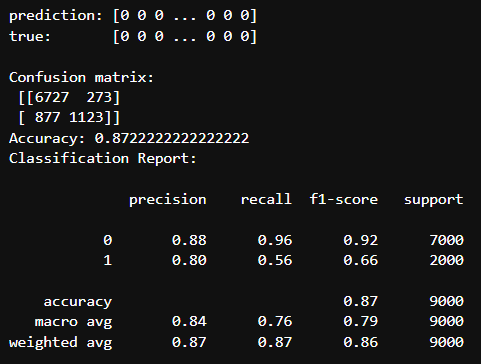

In [44]:
#saving the file as a .pkl
import joblib
joblib.dump(pipe, 'project.pkl')
print("הקובץ נשמר בהצלחה!")

הקובץ נשמר בהצלחה!
